In [2]:
import importlib
from tqdm.auto import tqdm
import os
import pickle
import sys
from pathlib import Path

# Add parent directory to path to allow imports from eval_utils
# For notebooks, add the parent of the current directory (where eval_utils is located)
parent_dir = Path(os.getcwd()).parent if Path(os.getcwd()).name == 'analysis' else Path(os.getcwd())
if str(parent_dir) not in sys.path:
    sys.path.insert(0, str(parent_dir))

os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import torch
import transformers
from transformers import AutoTokenizer, AutoModel
import numpy as np 
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd

from safetensors.torch import load_model
from model import GenderChunkedClassifier

from eval_utils.viz_utils import plot_error_bar, plot_violins
from eval_utils.inference_utils import load_generated_output, find_threshold_for_N, calculate_metrics

In [1]:
# import h5py
# data = h5py.File("/disk/10tb/home/chepurova/chepurova/human_data/valid.h5", "r")
# data.keys()
# data['HG02489']['chrY'][24_000_000:24_892_000].astype('str')

In [45]:
positions = []
attn_scores = []
probs = []
Ns = [300_000]

for N in Ns:
    test_dump = f'test_Y_ratio_None_X_ratio_None_{N}_human142_forced_y_sampling_True_with_chr_positions_and_attn_scores.pckl'
    test_sample2probs, test_sample2labels, test_sample2chromosomes, test_sample2att_scores = load_generated_output([test_dump])

    for sample_id, label in test_sample2labels.items():
    
        samples_array = test_sample2chromosomes[sample_id]
        attn_scores_array = test_sample2att_scores[sample_id]

        for i, sampled_chr in enumerate(samples_array):

            y_chr_positions = np.char.find(sampled_chr[:, 0], "Y") >= 0

            pos = sampled_chr[np.char.find(sampled_chr[:, 0], "Y") >= 0][:, 1:]
            pos = pos.astype('int')
            scores = attn_scores_array[i, :, y_chr_positions]
            print(scores, i, test_sample2probs[sample_id][i].item())
            if i > 10:
                break
            assert pos.shape[0] == scores.shape[0]

            for p in pos:
                probs.append(test_sample2probs[sample_id][i].item())

            attn_scores.extend(scores.copy())
            positions.extend(pos.copy())

# attn_scores = np.stack(attn_scores)
# positions = np.stack(positions)


[[-2.609375    0.07080078 17.5        -2.046875  ]] 0 0.439453125
[[ 1.3359375  1.5078125 -5.8125     0.8203125]] 1 0.5234375
[[-2.609375    0.07080078 17.5        -2.046875  ]] 2 0.427734375
[[-2.609375    0.07080078 17.5        -2.046875  ]] 3 0.4296875
[[ 1.4453125   0.86328125 -6.28125     0.98046875]] 4 0.515625
[[-2.609375    0.07080078 17.5        -2.046875  ]] 5 0.42578125
[[-2.609375    0.07080078 17.5        -2.046875  ]] 6 0.419921875
[[ 1.1015625   2.453125   -5.4375      0.61328125]
 [-2.609375    0.07080078 17.5        -2.046875  ]] 7 0.431640625
[[-2.609375    0.07080078 17.5        -2.046875  ]] 8 0.416015625
[[ 1.40625     1.2265625  -5.96875     0.87890625]] 9 0.51953125
[[ 0.7890625  3.75      -4.875      0.3203125]] 10 0.5078125
[[-2.609375    0.07080078 17.5        -2.046875  ]] 11 0.421875
[[ 1.5078125   0.73046875 -6.15625     0.984375  ]
 [-2.609375    0.07080078 17.5        -2.046875  ]] 0 0.43359375
[[-2.203125 14.0625    1.765625 -2.453125]] 1 0.0517578125
[[

In [6]:
len(attn_scores), len(positions), len(probs)

(535643, 535643, 535643)

<Axes: ylabel='Count'>

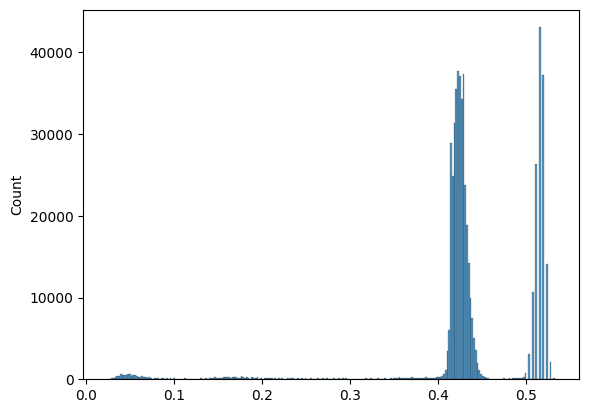

In [7]:
sns.histplot(probs)

<Axes: ylabel='Count'>

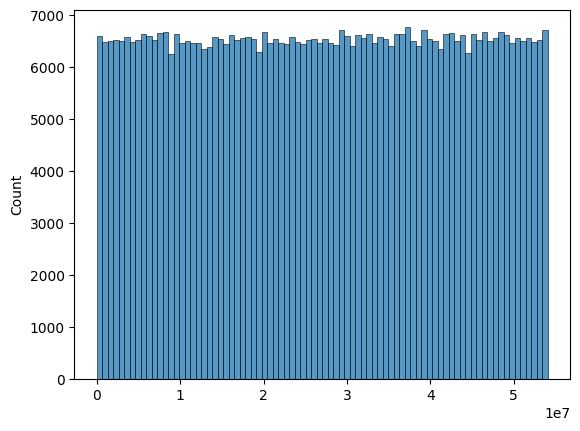

In [8]:
sns.histplot(positions[:, 0]) # log_scale=True)

In [9]:
positions[:, 0][positions[:, 0] < 1000]

array([294, 955, 913, 294, 955, 913])

<Axes: ylabel='Count'>

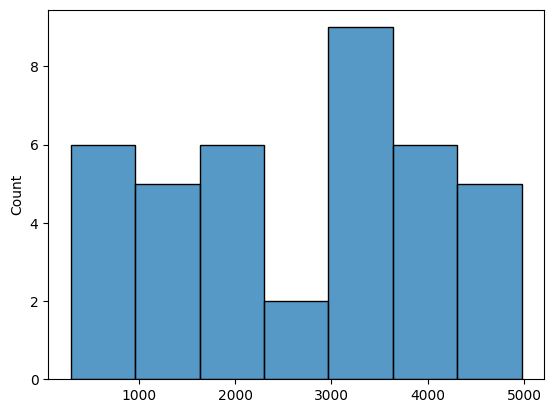

In [10]:
filtered_pos = positions[:, 0][positions[:, 0] < 5000]

sns.histplot(filtered_pos) # log_scale=True)

In [11]:
high_prob_positions = positions[np.where(np.array(probs) > 0.5), :][0, :, 0]
low_prob_positions = positions[np.where(np.array(probs) <= 0.50), :][0, :, 0]

In [12]:
high_prob_positions

array([11608568, 13419169, 16316995, ..., 14990645, 10779389,  4066839])

<Axes: ylabel='Count'>

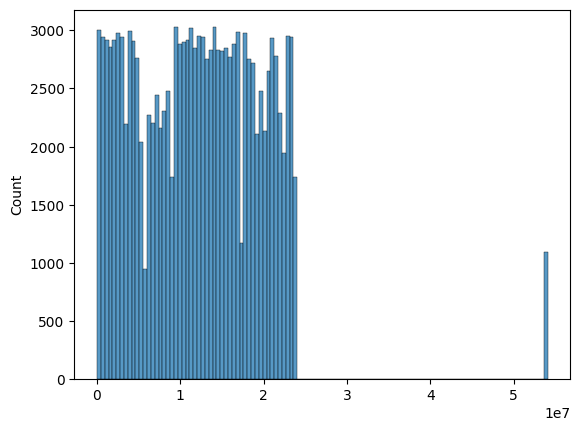

In [13]:
sns.histplot(high_prob_positions)
            #  , log_scale=True)

<Axes: ylabel='Count'>

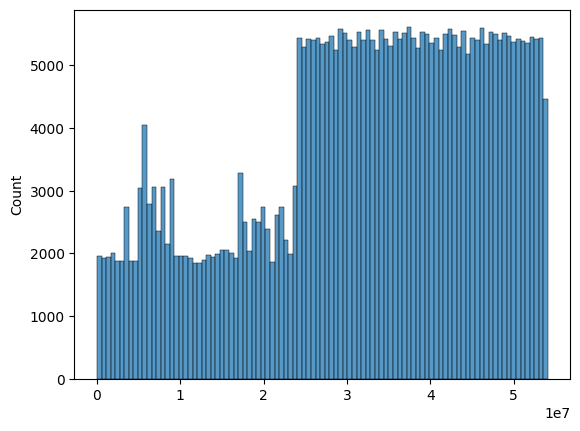

In [14]:
sns.histplot(low_prob_positions)
# log_scale=True)

<Axes: >

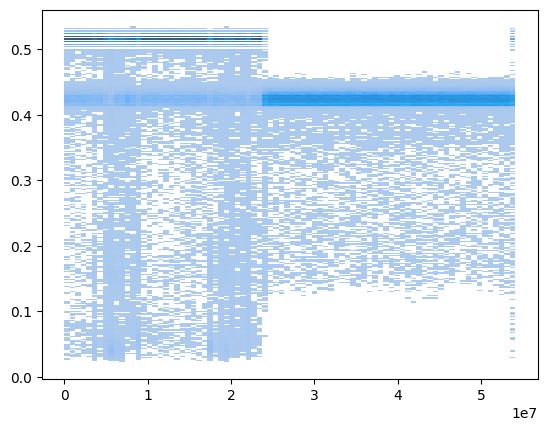

In [20]:
sns.histplot(x=positions[:, 0], y=probs)

<Axes: >

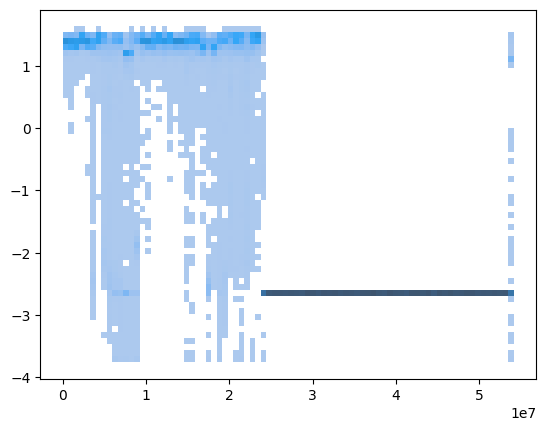

In [21]:
sns.histplot(x=positions[:, 0], y=attn_scores[:, 0])

<Axes: >

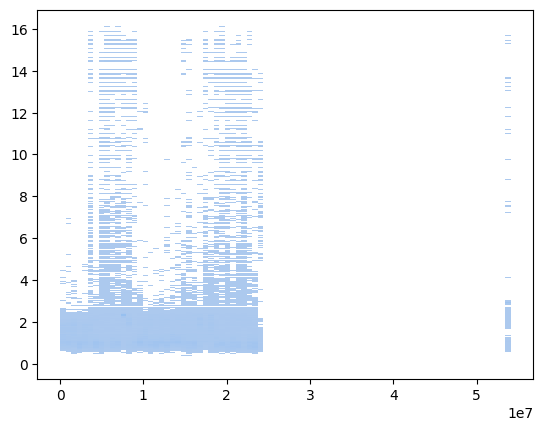

In [22]:
sns.histplot(x=positions[:, 0], y=attn_scores[:, 1])

<Axes: >

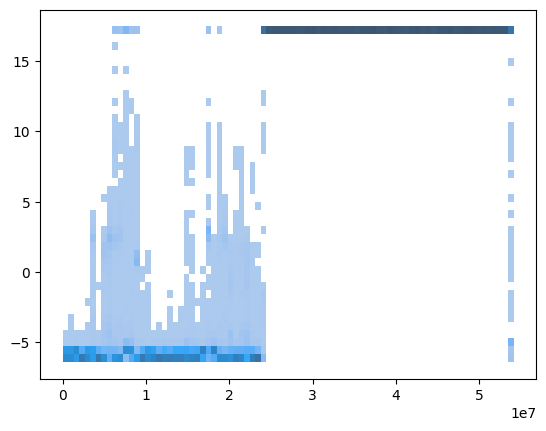

In [23]:
sns.histplot(x=positions[:, 0], y=attn_scores[:, 2])

<Axes: >

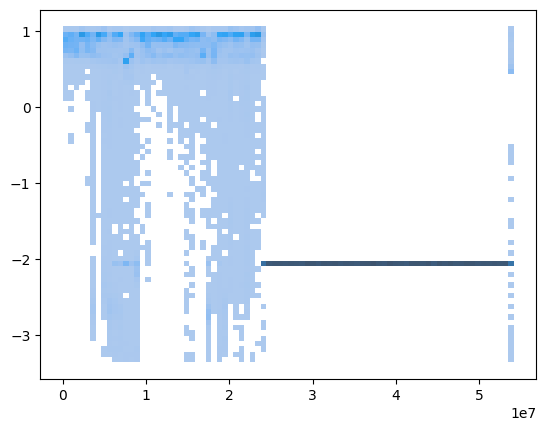

In [24]:
sns.histplot(x=positions[:, 0], y=attn_scores[:, 3])

## Preparing for IGV

In [25]:
import pandas as pd
from collections import defaultdict
from tqdm import tqdm
import numpy as np

In [26]:
N = 500_000
for i in range(4):
    df_dict = {'start_position': positions[:, 0], 'probability': probs, 'attention_score': attn_scores[:, i]}
    df = pd.DataFrame(df_dict)
    df.to_csv(f'{N}_samples_Y_chr_positions_probs_attn_scores_from_{i}_vector.csv')

In [28]:
def process_probabilities(input_file, output_bedgraph_prob, chrom="chrY", seq_length=3072):
    pos_dict = defaultdict(list)
    
    chunk_iter = pd.read_csv(input_file, chunksize=100000)
    for chunk in chunk_iter:
        for _, row in tqdm(chunk.iterrows(), total=len(chunk)):
            start_pos = row['start_position']
            probability = row['probability']
            
            for i in range(seq_length):
                pos = start_pos + i
                pos_dict[pos].append(probability)
    
    with open(output_bedgraph_prob, 'w') as f_prob:
        coverage = []
        f_prob.write(f'track type=bedGraph name="{output_bedgraph_prob}" description="Genomic scores" visibility=full autoScale=on\n')
        
        for pos in tqdm(sorted(pos_dict.keys()), total=len(pos_dict.keys())):
            mean_prob = np.mean(pos_dict[pos])
            coverage.append(len(pos_dict[pos]))
            f_prob.write(f'{chrom} {int(pos)} {int(pos+1)} {mean_prob}\n')
    
    print(f"Saved BEDGRAPH file: {output_bedgraph_prob}, mean coverage: {np.mean(coverage)}")

In [31]:
def process_attn_scores(input_file, output_bedgraph_att, chrom="chrY", seq_length=3072):
    pos_dict = defaultdict(list)
    
    chunk_iter = pd.read_csv(input_file, chunksize=100000)
    for chunk in chunk_iter:
        for _, row in tqdm(chunk.iterrows(), total=len(chunk)):
            start_pos = row['start_position']
            attention_score = row['attention_score']
            
            for i in range(seq_length):
                pos = start_pos + i
                pos_dict[pos].append(attention_score)
    
    with open(output_bedgraph_att, 'w') as f_att:
        f_att.write(f'track type=bedGraph name="{output_bedgraph_att}" description="Genomic scores" visibility=full autoScale=on\n')
        coverage = []

        for pos in tqdm(sorted(pos_dict.keys()), total=len(pos_dict.keys())):
            mean_att = np.mean(pos_dict[pos])
            coverage.append(len(pos_dict[pos]))
            f_att.write(f'{chrom} {int(pos)} {int(pos+1)} {mean_att}\n')
    
    print(f"Saved BEDGRAPH file: {output_bedgraph_att}, mean coverage: {np.mean(coverage)}")

In [30]:
N = 500_000
input_filename = f'{N}_samples_Y_chr_positions_probs_attn_scores_from_{0}_vector.csv'
output_probs = f'probabilities_from_{N}_samples.bedgraph'
process_probabilities(input_filename, output_probs)

100%|██████████| 54105959/54105959 [08:29<00:00, 106130.85it/s]


Saved BEDGRAPH file: probabilities_from_500000_samples.bedgraph, mean coverage: 30.412459670107687


In [ ]:
N = 500_000
for i in range(4):
    input_filename = f'{N}_samples_Y_chr_positions_probs_attn_scores_from_{i}_vector.csv'
    output_scores = f"attention_scores_from_{i}_vector_from_{N}_samples.bedgraph"
    process_attn_scores(input_filename, output_scores)

 66%|██████▌   | 35722664/54105959 [05:26<02:47, 109572.23it/s]